# Days 1-2 Live Trading Foundation Walkthrough

This notebook summarizes the read-only Kalshi live-trading foundation created in Days 1 and 2.

- **Day 1:** safe Kalshi configuration, secrets handling, read-only API client, and weather-market discovery.
- **Day 2:** contract bucket mapping, Open-Meteo-style live weather ingestion, scoreable live feature rows, and freshness diagnostics.

This is still a shadow/read-only workflow. It does **not** fetch order books, calculate edge, size trades, or submit orders.

## Setup

The cells below locate the repository root, load the generated Day 1/Day 2 artifacts, and set up simple plotting helpers.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    for parent in Path.cwd().parents:
        if (parent / "src").exists() and (parent / "config").exists():
            repo_root = parent
            break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

live_dir = repo_root / "outputs" / "live_trading"

paths = {
    "market_discovery": live_dir / "market_discovery_snapshot.csv",
    "contract_mapping": live_dir / "contract_bucket_mapping.csv",
    "live_weather": live_dir / "live_weather_snapshot.csv",
    "live_features": live_dir / "live_feature_rows.csv",
    "feature_freshness": live_dir / "live_feature_freshness.csv",
}

for name, path in paths.items():
    print(f"{name:18s} {path.exists()} {path.relative_to(repo_root)}")

market_discovery   True outputs\live_trading\market_discovery_snapshot.csv
contract_mapping   True outputs\live_trading\contract_bucket_mapping.csv
live_weather       True outputs\live_trading\live_weather_snapshot.csv
live_features      True outputs\live_trading\live_feature_rows.csv
feature_freshness  True outputs\live_trading\live_feature_freshness.csv


## What Day 1 Created

Day 1 created the safe read-only foundation:

- `config/trading_config.yaml`: defaults to `mode: shadow`, `trading_enabled: false`, and `live_auto_enabled: false`.
- `src/trading/secrets.py`: validates local Kalshi credentials without committing secrets.
- `src/trading/kalshi_client.py`: signs authenticated requests and supports safe GETs.
- `src/trading/market_discovery.py`: discovers NYC daily-high weather markets.
- `scripts/discover_weather_markets.py`: writes auditable market snapshots.
- `outputs/live_trading/market_discovery_snapshot.csv`: the Day 1 market-discovery output used as a Day 2 fixture.

The critical Day 1 safety outcome: the project can inspect markets, but there is no execution path.

In [2]:
market_discovery = pd.read_csv(paths["market_discovery"])

summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "events",
            "eligible rows",
            "unique tickers",
            "locations",
            "market types",
        ],
        "value": [
            len(market_discovery),
            market_discovery["event_ticker"].nunique(),
            int(market_discovery["eligible"].astype(bool).sum()),
            market_discovery["ticker"].nunique(),
            ", ".join(sorted(market_discovery["location"].dropna().astype(str).unique())),
            ", ".join(sorted(market_discovery["market_type"].dropna().astype(str).unique())),
        ],
    }
)
summary

,metric,value
0,rows,12
1,events,2
2,eligible rows,12
3,unique tickers,12
4,locations,NYC
5,market types,daily_high_temperature


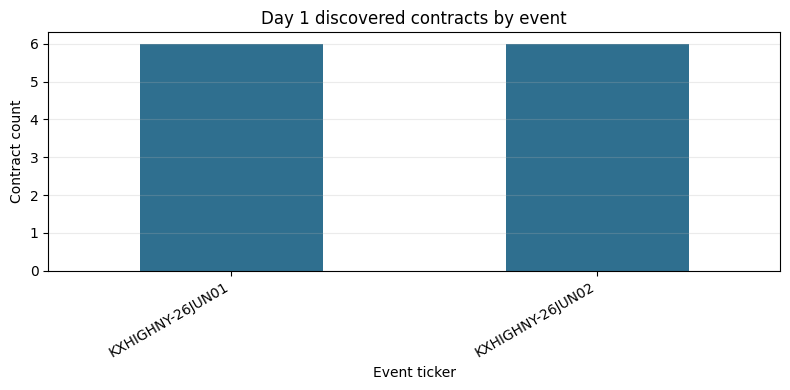

In [3]:
event_counts = market_discovery.groupby("event_ticker")["ticker"].count().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
event_counts.plot(kind="bar", ax=ax, color="#2f6f8f")
ax.set_title("Day 1 discovered contracts by event")
ax.set_xlabel("Event ticker")
ax.set_ylabel("Contract count")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [4]:
display_cols = [
    "event_ticker",
    "ticker",
    "status",
    "eligible",
    "subtitle",
    "yes_bid_dollars",
    "yes_ask_dollars",
    "close_time",
]
market_discovery[display_cols].head(12)

,event_ticker,ticker,status,eligible,subtitle,yes_bid_dollars,yes_ask_dollars,close_time
0,KXHIGHNY-26JUN02,KXHIGHNY-26JUN02-T80,active,True,81° or above,0.00,0.01,2026-06-03T04:59:00Z
1,KXHIGHNY-26JUN02,KXHIGHNY-26JUN02-T73,active,True,72° or below,0.00,0.01,2026-06-03T04:59:00Z
2,KXHIGHNY-26JUN02,KXHIGHNY-26JUN02-B79.5,active,True,79° to 80°,0.02,0.03,2026-06-03T04:59:00Z
3,KXHIGHNY-26JUN02,KXHIGHNY-26JUN02-B77.5,active,True,77° to 78°,0.27,0.28,2026-06-03T04:59:00Z
4,KXHIGHNY-26JUN02,KXHIGHNY-26JUN02-B75.5,active,True,75° to 76°,0.63,0.66,2026-06-03T04:59:00Z
5,KXHIGHNY-26JUN02,KXHIGHNY-26JUN02-B73.5,active,True,73° to 74°,0.07,0.08,2026-06-03T04:59:00Z
6,KXHIGHNY-26JUN01,KXHIGHNY-26JUN01-T77,active,True,78° or above,0.00,0.01,2026-06-02T04:59:00Z
7,KXHIGHNY-26JUN01,KXHIGHNY-26JUN01-T70,active,True,69° or below,0.00,0.01,2026-06-02T04:59:00Z
8,KXHIGHNY-26JUN01,KXHIGHNY-26JUN01-B76.5,active,True,76° to 77°,0.00,0.01,2026-06-02T04:59:00Z
9,KXHIGHNY-26JUN01,KXHIGHNY-26JUN01-B74.5,active,True,74° to 75°,0.00,0.01,2026-06-02T04:59:00Z


## What Day 2 Created

Day 2 turns discovered markets into model-compatible inputs:

- `src/trading/contract_mapping.py`: parses Kalshi rule/strike fields into final-temperature bucket intervals.
- `src/trading/live_weather.py`: fetches Open-Meteo-style current/forecast data and writes freshness diagnostics.
- `src/trading/live_features.py`: builds one live prediction row using the same feature definitions as the historical model.
- `scripts/build_live_feature_rows.py`: command-line entry point for the Day 2 flow.
- Day 2 outputs: contract mapping, weather snapshot, live feature row, and feature freshness table.

The current generated feature row is from `--dry-run-fixture`, so it validates the pipeline without live weather calls.

In [5]:
contract_mapping = pd.read_csv(paths["contract_mapping"])

mapping_cols = [
    "event_ticker",
    "ticker",
    "bucket_name",
    "bucket_lower_temp",
    "bucket_upper_temp",
    "mapping_status",
    "parse_source",
]
contract_mapping[mapping_cols]

,event_ticker,ticker,bucket_name,bucket_lower_temp,bucket_upper_temp,mapping_status,parse_source
0,KXHIGHNY-26JUN02,KXHIGHNY-26JUN02-T73,72deg or below,NaN,72.5,MAPPED,strike_fields
1,KXHIGHNY-26JUN02,KXHIGHNY-26JUN02-B73.5,73deg to 74deg,72.5,74.5,MAPPED,strike_fields
2,KXHIGHNY-26JUN02,KXHIGHNY-26JUN02-B75.5,75deg to 76deg,74.5,76.5,MAPPED,strike_fields
3,KXHIGHNY-26JUN02,KXHIGHNY-26JUN02-B77.5,77deg to 78deg,76.5,78.5,MAPPED,strike_fields
4,KXHIGHNY-26JUN02,KXHIGHNY-26JUN02-B79.5,79deg to 80deg,78.5,80.5,MAPPED,strike_fields
5,KXHIGHNY-26JUN02,KXHIGHNY-26JUN02-T80,81deg or above,80.5,NaN,MAPPED,strike_fields


### Contract Mapping Visual

The model uses lower-open, upper-closed intervals: `lower < actual_high <= upper`. Day 2 maps Kalshi's integer strike language into those half-degree settlement boundaries.

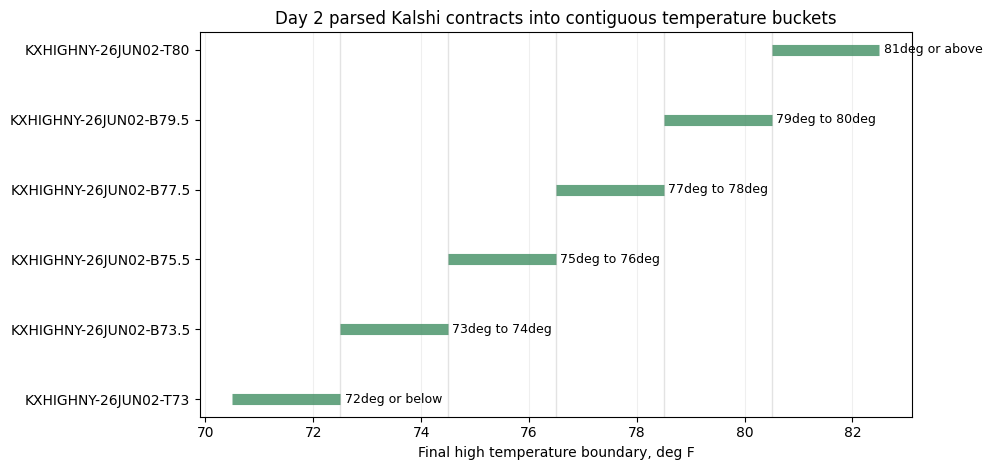

In [6]:
mapped = contract_mapping[contract_mapping["mapping_status"] == "MAPPED"].copy()
mapped["plot_lower"] = mapped["bucket_lower_temp"].fillna(mapped["bucket_upper_temp"].min() - 2)
mapped["plot_upper"] = mapped["bucket_upper_temp"].fillna(mapped["bucket_lower_temp"].max() + 2)
mapped = mapped.sort_values(["plot_lower", "plot_upper"])

fig, ax = plt.subplots(figsize=(10, 4.8))
y_positions = np.arange(len(mapped))
for y, (_, row) in zip(y_positions, mapped.iterrows()):
    ax.hlines(
        y,
        row["plot_lower"],
        row["plot_upper"],
        linewidth=8,
        color="#4c956c",
        alpha=0.85,
    )
    ax.text(row["plot_upper"] + 0.08, y, row["bucket_name"], va="center", fontsize=9)

for boundary in sorted(set(mapped["bucket_upper_temp"].dropna()).union(set(mapped["bucket_lower_temp"].dropna()))):
    ax.axvline(boundary, color="#444", alpha=0.15, linewidth=1)

ax.set_yticks(y_positions)
ax.set_yticklabels(mapped["ticker"])
ax.set_xlabel("Final high temperature boundary, deg F")
ax.set_title("Day 2 parsed Kalshi contracts into contiguous temperature buckets")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()

In [7]:
boundaries = mapped[["bucket_lower_temp", "bucket_upper_temp"]].reset_index(drop=True)
gap_check = []
for i in range(1, len(boundaries)):
    previous_upper = boundaries.loc[i - 1, "bucket_upper_temp"]
    current_lower = boundaries.loc[i, "bucket_lower_temp"]
    gap_check.append(
        {
            "left_bucket": mapped.iloc[i - 1]["bucket_name"],
            "right_bucket": mapped.iloc[i]["bucket_name"],
            "previous_upper": previous_upper,
            "current_lower": current_lower,
            "contiguous": bool(np.isclose(previous_upper, current_lower)),
        }
    )

pd.DataFrame(gap_check)

,left_bucket,right_bucket,previous_upper,current_lower,contiguous
0,72deg or below,73deg to 74deg,72.5,72.5,True
1,73deg to 74deg,75deg to 76deg,74.5,74.5,True
2,75deg to 76deg,77deg to 78deg,76.5,76.5,True
3,77deg to 78deg,79deg to 80deg,78.5,78.5,True
4,79deg to 80deg,81deg or above,80.5,80.5,True


## Live Feature Row

Day 2 creates a model-ready row with the exact 36 selected model features from `outputs/final_feature_list.json`, plus metadata used for auditability. The generated row below is a dry-run fixture row, not a live-weather row.

In [8]:
live_features = pd.read_csv(paths["live_features"])
freshness = pd.read_csv(paths["feature_freshness"])

metadata_cols = [
    "row_id",
    "date",
    "prediction_time",
    "location",
    "event_ticker",
    "forecast_high",
    "bucket_count",
    "mapping_status",
    "weather_status",
    "live_feature_status",
    "no_trade_reason",
]
live_features[metadata_cols]

,row_id,date,prediction_time,location,event_ticker,forecast_high,bucket_count,mapping_status,weather_status,live_feature_status,no_trade_reason
0,dry_run:KXHIGHNY-26JUN02:0,2022-01-01,2022-01-01 00:00:00,NYC,KXHIGHNY-26JUN02,54.3,6,MAPPED,DRY_RUN_FIXTURE,SCOREABLE_SHADOW,dry_run_fixture_not_live_weather


In [9]:
feature_cols = [column for column in live_features.columns if column not in metadata_cols and column != "target_date" and column != "prediction_timestamp"]
feature_summary = pd.DataFrame(
    {
        "feature_count": [len(feature_cols)],
        "missing_feature_values": [int(live_features[feature_cols].isna().sum(axis=1).iloc[0])],
        "infinite_feature_values": [int(np.isinf(live_features[feature_cols].to_numpy(dtype=float)).sum())],
    }
)
feature_summary

,feature_count,missing_feature_values,infinite_feature_values
0,36,7,0


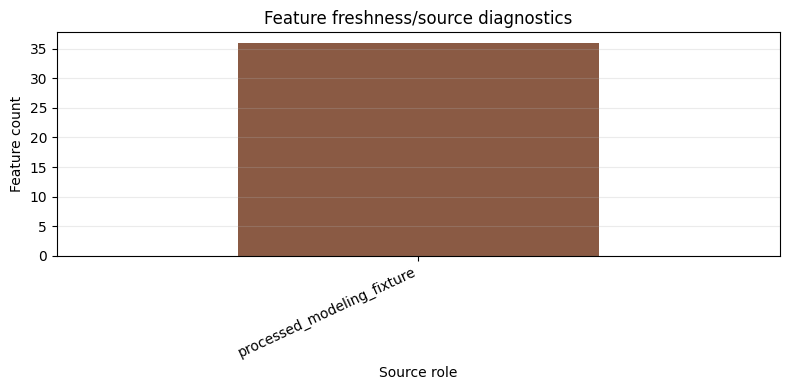

In [10]:
freshness_by_source = freshness.groupby("source_role")["feature"].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
freshness_by_source.plot(kind="bar", ax=ax, color="#8a5a44")
ax.set_title("Feature freshness/source diagnostics")
ax.set_xlabel("Source role")
ax.set_ylabel("Feature count")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

## Scoreability Example

Day 2's feature row can be handed to the existing probability engine. The example below loads the saved NGBoost engine, scores the feature row, converts the mapped Kalshi bucket intervals into `TemperatureBucket` objects, and computes probabilities for the live contract buckets.

This is still not a trading decision. Day 3 will add executable order books, fees, spread, slippage, liquidity, and edge logic.

In [11]:
from src.bucket_schema import TemperatureBucket
from src.predict_distribution import load_probability_engine

engine = load_probability_engine()
params = engine.predict_distribution_params(live_features)
params[["row_id", "forecast_high", "mu", "sigma", "distribution_type", "model_name"]]

,row_id,forecast_high,mu,sigma,distribution_type,model_name
0,dry_run:KXHIGHNY-26JUN02:0,54.3,-1.613912,1.405347,laplace,ngboost_laplace_current36_default


In [12]:
buckets = [
    TemperatureBucket(
        label=row["bucket_name"],
        lower_temp=None if pd.isna(row["bucket_lower_temp"]) else float(row["bucket_lower_temp"]),
        upper_temp=None if pd.isna(row["bucket_upper_temp"]) else float(row["bucket_upper_temp"]),
    )
    for _, row in mapped.iterrows()
]

prediction = engine.predict(live_features, buckets=buckets)
bucket_probs = prediction.bucket_probabilities.merge(
    mapped[["bucket_name", "ticker"]],
    on="bucket_name",
    how="left",
)

prob_cols = ["ticker", "bucket_name", "bucket_lower_temp", "bucket_upper_temp", "probability", "error_lower", "error_upper"]
bucket_probs[prob_cols]

,ticker,bucket_name,bucket_lower_temp,bucket_upper_temp,probability,error_lower,error_upper
0,KXHIGHNY-26JUN02-T73,72deg or below,NaN,72.5,9.999996e-01,NaN,18.2
1,KXHIGHNY-26JUN02-B73.5,73deg to 74deg,72.5,74.5,2.858522e-07,18.2,20.2
2,KXHIGHNY-26JUN02-B75.5,75deg to 76deg,74.5,76.5,6.887812e-08,20.2,22.2
3,KXHIGHNY-26JUN02-B77.5,77deg to 78deg,76.5,78.5,1.659668e-08,22.2,24.2
4,KXHIGHNY-26JUN02-B79.5,79deg to 80deg,78.5,80.5,3.999088e-09,24.2,26.2
5,KXHIGHNY-26JUN02-T80,81deg or above,80.5,NaN,1.269505e-09,26.2,NaN


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_probs = bucket_probs.sort_values("bucket_index")
ax.bar(plot_probs["bucket_name"], plot_probs["probability"], color="#3f7cac")
ax.set_title("Model probabilities for mapped Kalshi buckets")
ax.set_xlabel("Mapped bucket")
ax.set_ylabel("Probability")
ax.set_ylim(0, max(0.05, float(plot_probs["probability"].max()) * 1.2))
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

## Commands To Reproduce

Day 1 market discovery:

```bash
python scripts/discover_weather_markets.py
```

Day 2 dry-run feature build using the saved discovery snapshot and processed modeling fixture:

```bash
python scripts/build_live_feature_rows.py --dry-run-fixture
```

Day 2 real live-weather feature build:

```bash
python scripts/build_live_feature_rows.py --event-ticker KXHIGHNY-26JUN02 --target-date 2026-06-02 --prediction-time 2026-06-02T12:00:00
```

A real run should rediscover the current target date/event first. The saved June 2026 snapshot is useful as a fixture, not as a claim that the same contracts are currently tradable.

## Safety Notes

- Day 1 and Day 2 are read-only/shadow foundations.
- `trading_enabled` remains false by default.
- Missing, stale, ambiguous, or timestamp-unsafe data produces diagnostics instead of orders.
- Forecast issue/run timestamps remain a known limitation for the current Open-Meteo proxy path.
- No order books, edge calculations, position reconciliation, risk sizing, or broker modules are used here.